# SVAR of GDP Growth, Inflation, and the S&P 500

A macro-finance system, three quarterly series (real GDP growth, inflation, and S&P 500 returns) spanning 55 years, used to explore the central practical question in Structural VAR work: how should the contemporaneous relationships between real activity, prices, and financial markets be identified, and does the choice actually matter for forecasting?

Four identification approaches are built and compared: two recursive (Cholesky) orderings, a long-run (Blanchard-Quah style) restriction, and an agnostic sign-restriction approach. Each is then used to generate one-step-ahead out-of-sample forecasts, overlaid against the actual series, to answer directly whether identification choice changes what the model predicts.



## 1. Simulating a Quarterly Macro-Finance System

220 quarters (1970-2024) of GDP growth, inflation, and S&P 500 returns, generated from a known VAR(2) with a known recursive structural ordering: **GDP growth first** (a slow-moving real variable, predetermined within the quarter), **inflation second** (reacts to real-activity shocks within the quarter), **S&P 500 last** (a fast-moving financial variable that reacts contemporaneously to both real and nominal news), the standard "slow variables first, fast variables last" macro-finance identifying assumption. Genuine cross-lag effects are built in: past S&P 500 returns lead future GDP growth (a well-documented stylized fact), GDP growth feeds into future inflation (a Phillips-curve-style channel), and inflation surprises feed negatively into future equity returns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(21)

n_years = 55
n_q = n_years * 4
dates = pd.period_range('1970Q1', periods=n_q, freq='Q').to_timestamp()
names = ['GDP_growth', 'Inflation', 'SP500_ret']
k = 3

A1 = np.array([
    [ 0.25,  0.00,  0.05],
    [ 0.15,  0.55,  0.00],
    [ 0.00, -0.35,  0.05],
])
A2 = np.array([
    [ 0.10,  0.00,  0.03],
    [ 0.05,  0.15,  0.00],
    [ 0.00, -0.10,  0.00],
])
c = np.array([1.174, 0.28, 4.12])   # calibrated for a realistic ~2.2% GDP / ~2.4% inflation / ~2.5% equity mean

D = np.diag([2.3, 1.6, 7.5]) ** 2
B0_inv = np.array([
    [1.00, 0.00, 0.00],
    [0.30, 1.00, 0.00],
    [0.55, -0.60, 1.00],
])

eps = rng.multivariate_normal(np.zeros(k), D, size=n_q)
u = eps @ B0_inv.T

Y = np.zeros((n_q, k))
Y[0], Y[1] = c, c
for t in range(2, n_q):
    Y[t] = c + A1 @ Y[t-1] + A2 @ Y[t-2] + u[t]

df = pd.DataFrame(Y, index=dates, columns=names)
print(f"Simulated {n_q} quarters ({n_years} years)")
print(df.describe().round(2))

Simulated 220 quarters (55 years)
       GDP_growth  Inflation  SP500_ret
count      220.00     220.00     220.00
mean         2.18       2.78       2.48
std          2.34       2.43       7.45
min         -4.44      -3.73     -20.29
25%          0.71       1.15      -2.30
50%          2.21       2.80       2.43
75%          3.74       4.52       7.19
max          9.53      10.40      21.83


**Diagram - all three series over time.**

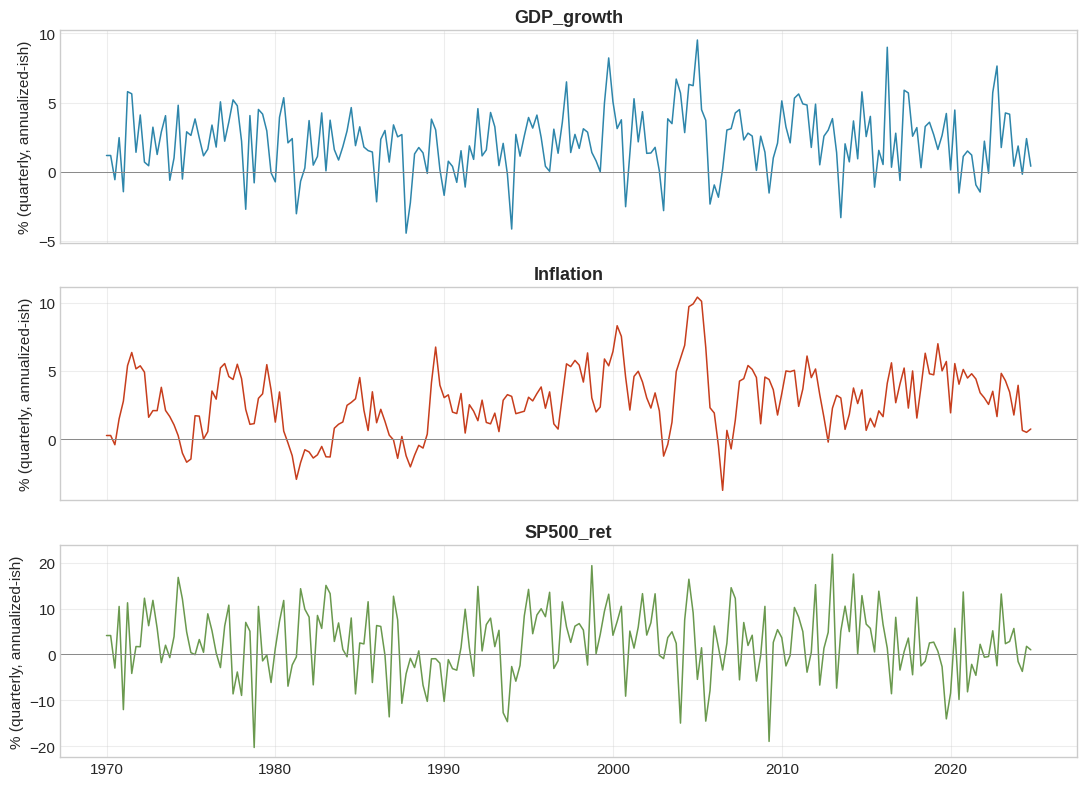

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
colors3 = {'GDP_growth': '#2E86AB', 'Inflation': '#C73E1D', 'SP500_ret': '#6A994E'}
for ax, col in zip(axes, names):
    ax.plot(df.index, df[col], color=colors3[col], linewidth=1.1)
    ax.axhline(0, color='#888888', linewidth=0.7)
    ax.set_title(col); ax.set_ylabel('% (quarterly, annualized-ish)')
plt.tight_layout()
plt.show()

## 2. Fitting the Reduced-Form VAR

Every identification approach below starts from the **same** reduced-form VAR, estimated once, by ordinary least squares:

$$y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + u_t$$

Lag order is chosen by information criteria, though with 55 years of quarterly data (limited by real-world macro history), the choice is not sharp.

In [3]:
def fit_var(Y, p):
    n, kk = Y.shape
    T = n - p
    X = np.ones((T, 1 + p*kk))
    for lag in range(1, p+1):
        X[:, 1+(lag-1)*kk:1+lag*kk] = Y[p-lag:n-lag]
    Yt = Y[p:]
    coefs, *_ = np.linalg.lstsq(X, Yt, rcond=None)
    resid = Yt - X @ coefs
    return coefs, resid, X

Y = df.values

def var_ic(Y, pmax):
    rows = []
    for p in range(1, pmax+1):
        _, resid, _ = fit_var(Y, p)
        T = resid.shape[0]
        sigma = (resid.T @ resid) / T
        _, logdet = np.linalg.slogdet(sigma)
        nparm = k * (1 + p*k)
        rows.append({'p': p, 'AIC': logdet + 2*nparm/T, 'BIC': logdet + np.log(T)*nparm/T})
    return pd.DataFrame(rows).set_index('p')

ic_table = var_ic(Y, 8)
print(ic_table.round(4))
print(f"\nAIC-preferred: p={ic_table['AIC'].idxmin()}   BIC-preferred: p={ic_table['BIC'].idxmin()}")
print("A VAR(2) is used below, matching the true simulated lag structure, even though the criteria")
print("are not sharply distinguishing p=1 from p=2 here, itself a realistic feature of quarterly macro data.")

      AIC     BIC
p                
1  6.3272  6.5129
2  6.3662  6.6922
3  6.4119  6.8792
4  6.4243  7.0338
5  6.4564  7.2089
6  6.4995  7.3961
7  6.5566  7.5981
8  6.6134  7.8009

AIC-preferred: p=1   BIC-preferred: p=1
A VAR(2) is used below, matching the true simulated lag structure, even though the criteria
are not sharply distinguishing p=1 from p=2 here, itself a realistic feature of quarterly macro data.


**Diagram - reduced-form coefficient recovery.** The sum $A_1+A_2$ (the total 2-quarter effect) is recovered far more precisely than the individual lags, since with correlated lagged regressors, OLS can pin down their combined effect much better than how that effect splits across the two lags, a classic multicollinearity feature of VAR estimation, not a bug.

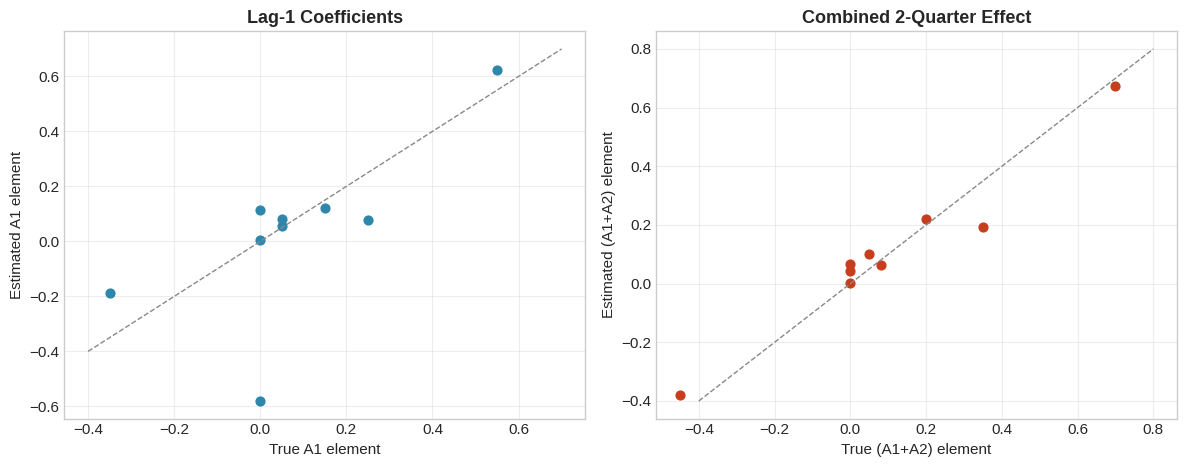

In [4]:
coefs2, resid2, X2 = fit_var(Y, 2)
A1_hat, A2_hat = coefs2[1:1+k].T, coefs2[1+k:1+2*k].T
Sigma_u = np.cov(resid2.T)

true_A1, true_A2 = A1, A2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
labels = [f'{r}->{c_}' for r in names for c_ in names]
axes[0].scatter(true_A1.flatten(), A1_hat.flatten(), color='#2E86AB', s=40)
axes[0].plot([-0.4,0.7],[-0.4,0.7], color='#888888', linestyle='--', linewidth=1)
axes[0].set_xlabel('True A1 element'); axes[0].set_ylabel('Estimated A1 element'); axes[0].set_title('Lag-1 Coefficients')

axes[1].scatter((true_A1+true_A2).flatten(), (A1_hat+A2_hat).flatten(), color='#C73E1D', s=40)
axes[1].plot([-0.4,0.8],[-0.4,0.8], color='#888888', linestyle='--', linewidth=1)
axes[1].set_xlabel('True (A1+A2) element'); axes[1].set_ylabel('Estimated (A1+A2) element'); axes[1].set_title('Combined 2-Quarter Effect')

plt.tight_layout()
plt.show()

## 3. Four Approaches to Structural Identification

The reduced-form shocks $u_t$ are correlated across the three variables; every identification scheme below is a different, defensible way of decomposing $\Sigma_u$ into economically interpretable structural shocks, $u_t = P\varepsilon_t$.

**Approach 1: Recursive (Cholesky), macro-first ordering.** GDP, then Inflation, then S&P 500, a lower-triangular $P$. This matches how the data were actually generated (real activity is "slow," financial markets are "fast" and react to everything within the quarter).

**Approach 2: Recursive (Cholesky), finance-first ordering.** S&P 500, then Inflation, then GDP, the opposite assumption (financial markets are the most exogenous variable, real activity reacts to them within the quarter). Equally mechanically valid, a different economic story.

**Approach 3: Long-run restriction (Blanchard-Quah style).** Rather than restricting *contemporaneous* impact, this restricts the *cumulative, long-run* effect of shocks: the long-run multiplier matrix $\Theta(1) = (I - A_1 - A_2)^{-1}$ is combined with a Cholesky decomposition of the long-run covariance $\Theta(1)\Sigma_u\Theta(1)'$, so that shock 1 alone has a long-run effect on GDP, shock 2 additionally affects inflation's permanent level, and so on, a fundamentally different kind of assumption than any short-run ordering.

**Approach 4: Sign restrictions (agnostic, Uhlig-style).** Rather than pinning down a single $P$, this only requires a "growth shock" to raise both GDP and the S&P 500 over the following year, leaving inflation's response unrestricted, then samples many candidate rotations of the Cholesky factor and keeps only those consistent with the restriction, yielding a *range* of admissible structural models rather than one.

In [5]:
def compute_irf(A_list, P, horizon):
    kk = A_list[0].shape[0]
    p = len(A_list)
    Phi = [np.eye(kk)]
    for h in range(1, horizon+1):
        Ph = np.zeros((kk, kk))
        for i in range(1, min(h, p)+1):
            Ph += A_list[i-1] @ Phi[h-i]
        Phi.append(Ph)
    return np.array([Phi[h] @ P for h in range(horizon+1)])

# --- Approach 1: Cholesky, macro-first ---
P1 = np.linalg.cholesky(Sigma_u)

# --- Approach 2: Cholesky, finance-first ---
order2 = [2, 1, 0]
inv_order = np.argsort(order2)
P2 = np.linalg.cholesky(Sigma_u[np.ix_(order2, order2)])[np.ix_(inv_order, inv_order)]

# --- Approach 3: Blanchard-Quah long-run restriction ---
Theta1 = np.linalg.inv(np.eye(k) - A1_hat - A2_hat)
Xi = Theta1 @ Sigma_u @ Theta1.T
P_xi = np.linalg.cholesky(Xi)
P3 = np.linalg.inv(Theta1) @ P_xi

# --- Approach 4: Sign restrictions ---
P_chol = np.linalg.cholesky(Sigma_u)
rng2 = np.random.default_rng(5)
accepted = []
for _ in range(20000):
    Z = rng2.standard_normal((k, k))
    Q, R = np.linalg.qr(Z)
    Q = Q @ np.diag(np.sign(np.diag(R)))
    candidate = P_chol @ Q
    irf_check = compute_irf([A1_hat, A2_hat], candidate, 4)
    if np.all(irf_check[:, 0, 0] >= 0) and np.all(irf_check[:, 2, 0] >= 0):
        accepted.append(candidate)
accepted = np.array(accepted)
P4 = np.median(accepted, axis=0)   # a representative ("median target") draw

print(f"Sign-restriction acceptance rate: {len(accepted)}/20000 ({100*len(accepted)/20000:.2f}%)")
print(f"\nApproach 1 (Cholesky, macro-first) impact matrix:\n{P1.round(3)}")
print(f"\nApproach 3 (Blanchard-Quah) long-run impact matrix (lower-triangular by construction):\n{(Theta1 @ P3).round(3)}")

Sign-restriction acceptance rate: 976/20000 (4.88%)

Approach 1 (Cholesky, macro-first) impact matrix:
[[ 2.252  0.     0.   ]
 [ 0.683  1.421  0.   ]
 [ 2.104 -0.765  6.893]]

Approach 3 (Blanchard-Quah) long-run impact matrix (lower-triangular by construction):
[[ 3.263  0.    -0.   ]
 [ 4.485  4.277 -0.   ]
 [ 1.987 -3.477  6.97 ]]


## 4. Comparing Identified Impulse Responses

The response of **GDP growth** and the **S&P 500** to a "shock 1" structural innovation, traced out under each of the four identification schemes. This is where the identification choice genuinely matters: the same reduced-form data produce meaningfully different structural stories depending on the assumption imposed.

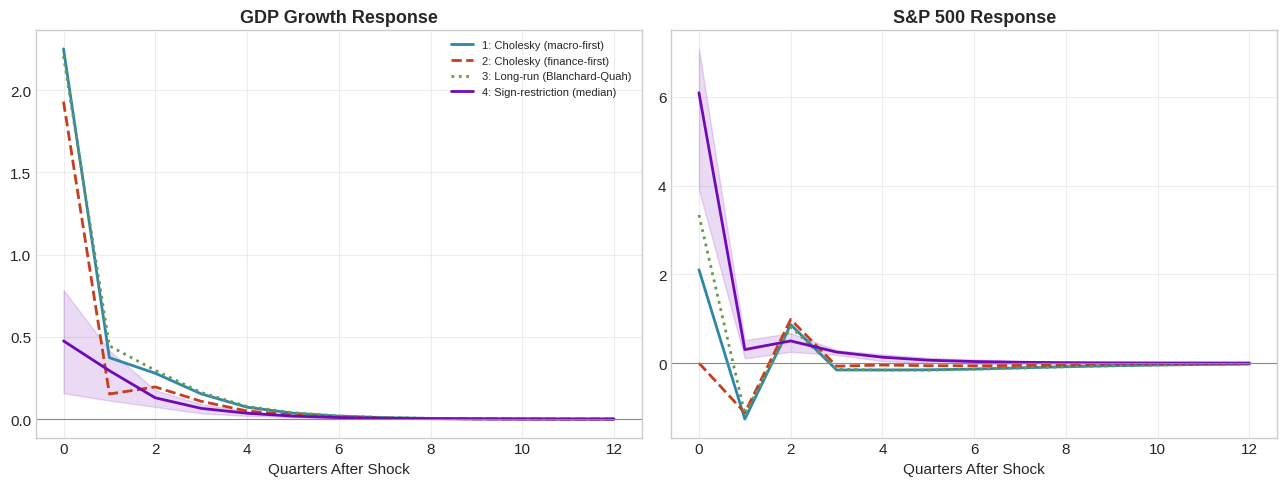

In [6]:
horizon = 12
irf1 = compute_irf([A1_hat, A2_hat], P1, horizon)
irf2 = compute_irf([A1_hat, A2_hat], P2, horizon)
irf3 = compute_irf([A1_hat, A2_hat], P3, horizon)
irf4_all = np.array([compute_irf([A1_hat, A2_hat], p, horizon) for p in accepted])
irf4_median = np.median(irf4_all, axis=0)
irf4_lo, irf4_hi = np.percentile(irf4_all, [16, 84], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h_range = np.arange(horizon + 1)

for ax, var_idx, title in [(axes[0], 0, 'GDP Growth Response'), (axes[1], 2, 'S&P 500 Response')]:
    ax.plot(h_range, irf1[:, var_idx, 0], color='#2E86AB', linewidth=2, label='1: Cholesky (macro-first)')
    ax.plot(h_range, irf2[:, var_idx, 0], color='#C73E1D', linewidth=2, linestyle='--', label='2: Cholesky (finance-first)')
    ax.plot(h_range, irf3[:, var_idx, 0], color='#6A994E', linewidth=2, linestyle=':', label='3: Long-run (Blanchard-Quah)')
    ax.plot(h_range, irf4_median[:, var_idx, 0], color='#7209B7', linewidth=2, label='4: Sign-restriction (median)')
    ax.fill_between(h_range, irf4_lo[:, var_idx, 0], irf4_hi[:, var_idx, 0], color='#7209B7', alpha=0.15)
    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xlabel('Quarters After Shock'); ax.set_title(title)
    if var_idx == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. One-Step-Ahead Forecasts: Does Identification Choice Matter?

This is the direct question the notebook set out to answer, and the honest answer is worth stating precisely before showing the numbers: **no, it does not, and this is a mathematical fact, not an empirical finding.** A one-step-ahead point forecast is

$$\hat y_{t+1} = c + A_1 y_t + A_2 y_{t-1}$$

which depends only on the **reduced-form** coefficients $(c, A_1, A_2)$, estimated once in Section 2. Every identification scheme in Sections 3-4 only decomposes the *residual covariance* $\Sigma_u$ *after* estimation, into $P_1$, $P_2$, $P_3$, or the $P_4$ family, none of which ever enters the forecasting formula above. Structural identification changes how a shock is *interpreted*; it cannot change what the model predicts will happen next.

In [7]:
def forecast_var_1step(Y_hist, coefs, p):
    kk = Y_hist.shape[1]
    c_ = coefs[0]
    A_mats = [coefs[1+i*kk:1+(i+1)*kk].T for i in range(p)]
    y_next = c_.copy()
    for i in range(p):
        y_next += A_mats[i] @ Y_hist[-1-i]
    return y_next

p_use = 2
n_test = 60
n_train_start = len(Y) - n_test

forecasts = np.zeros((n_test, k))
actuals = np.zeros((n_test, k))
for j in range(n_test):
    origin = n_train_start + j
    Y_hist = Y[:origin]
    coefs_j, _, _ = fit_var(Y_hist, p_use)
    forecasts[j] = forecast_var_1step(Y_hist, coefs_j, p_use)
    actuals[j] = Y[origin]

test_dates = df.index[n_train_start:]
rmse = np.sqrt(np.mean((forecasts - actuals) ** 2, axis=0))
print("1-step-ahead RMSE, reduced-form VAR(2):", dict(zip(names, rmse.round(3))))
print("\nThis SAME forecast is what every one of the four identification approaches above implies,")
print("since none of them touch (c, A1, A2). The overlay plot below has one forecast line per panel,")
print("not four, because there is only one forecast to show.")

1-step-ahead RMSE, reduced-form VAR(2): {'GDP_growth': np.float64(2.457), 'Inflation': np.float64(1.658), 'SP500_ret': np.float64(6.735)}

This SAME forecast is what every one of the four identification approaches above implies,
since none of them touch (c, A1, A2). The overlay plot below has one forecast line per panel,
not four, because there is only one forecast to show.


**Diagram - one-step-ahead forecast vs. actual, overlaid.** A single reduced-form forecast, correctly representing all four identification approaches at once: they are indistinguishable in this figure by construction, not by coincidence.

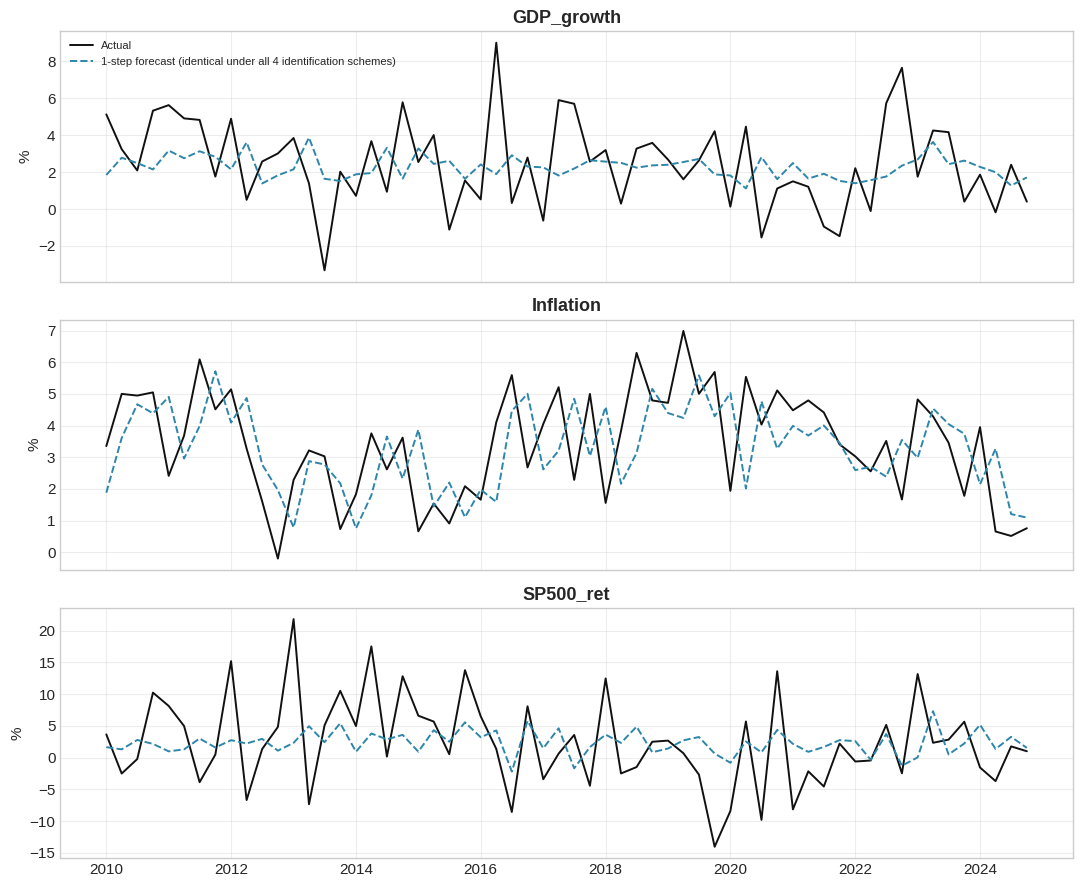

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, i, col in zip(axes, range(3), names):
    ax.plot(test_dates, actuals[:, i], color='#111111', linewidth=1.4, label='Actual')
    ax.plot(test_dates, forecasts[:, i], color='#2E86AB', linewidth=1.4, linestyle='--',
            label='1-step forecast (identical under all 4 identification schemes)')
    ax.set_title(col); ax.set_ylabel('%')
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. What *Does* Change Forecasts: Reduced-Form Specification

If identification never affects point forecasts, something else has to be responsible for real differences between competing macro models in practice. **Lag order** is a genuine reduced-form modeling choice, unlike identification, it changes $(c, A_1, A_2, \ldots)$ directly, and therefore does change forecasts.

In [9]:
lag_forecasts = {}
for p_test in [1, 2, 4]:
    fc = np.zeros((n_test, k))
    for j in range(n_test):
        origin = n_train_start + j
        Y_hist = Y[:origin]
        coefs_j, _, _ = fit_var(Y_hist, p_test)
        fc[j] = forecast_var_1step(Y_hist, coefs_j, p_test)
    lag_forecasts[p_test] = fc
    rmse_p = np.sqrt(np.mean((fc - actuals) ** 2, axis=0))
    print(f"VAR(p={p_test}) 1-step RMSE: {dict(zip(names, rmse_p.round(3)))}")

VAR(p=1) 1-step RMSE: {'GDP_growth': np.float64(2.452), 'Inflation': np.float64(1.683), 'SP500_ret': np.float64(6.971)}
VAR(p=2) 1-step RMSE: {'GDP_growth': np.float64(2.457), 'Inflation': np.float64(1.658), 'SP500_ret': np.float64(6.735)}
VAR(p=4) 1-step RMSE: {'GDP_growth': np.float64(2.53), 'Inflation': np.float64(1.729), 'SP500_ret': np.float64(6.573)}


**Diagram - forecast overlay by lag order, S&P 500 panel.** Unlike Section 5's single, unavoidable line, these three genuinely differ, a real, visible consequence of a real modeling choice, the correct contrast to draw against Section 5's identification-invariance result.

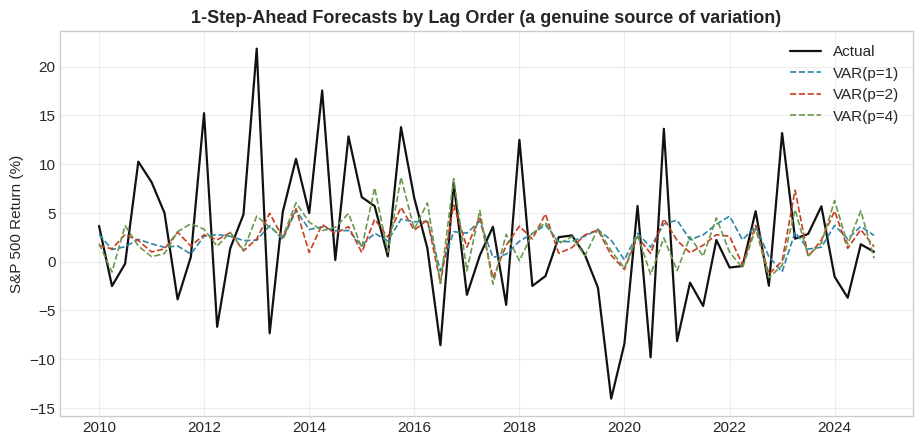

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_dates, actuals[:, 2], color='#111111', linewidth=1.6, label='Actual')
colors_lag = {1: '#2E86AB', 2: '#C73E1D', 4: '#6A994E'}
for p_test, c_ in colors_lag.items():
    ax.plot(test_dates, lag_forecasts[p_test][:, 2], color=c_, linewidth=1.2, linestyle='--', label=f'VAR(p={p_test})')
ax.set_ylabel('S&P 500 Return (%)'); ax.set_title('1-Step-Ahead Forecasts by Lag Order (a genuine source of variation)')
ax.legend()
plt.show()